# EUROPEAN CALL OPTION BLACK SCHOLES

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [2]:
#risk free rate
r = 0.05

#risk
sig = 0.2

#strike price
K = 1.

#time to maturity
T = 1.

#width of transformed S coordinate
w = 1.2

## Transformed Coordinate setup in $(\tau, x)$ and initial + boundary conditions

$$ \tau = T - t, \quad \tau (t=0) = T, \quad \tau (t=T) = 0 $$

$$ x = ln (\frac{S}{K}) , \quad x(S = K e^{-w}) = - w, \quad x(S = K e^{+w}) = w$$

$$ \partial_\tau f = \frac{1}{2} \sigma^2 \partial^2_x f + (r - \frac{1}{2}\sigma^2) \partial_x f - r f$$

$$ f(\tau =0, x) = max(K e^x - K, 0 )$$

$$ f(\tau, x = -w) = 0$$

$$ f(\tau, x = w) = K(e^w - e^{-r \tau})$$



## Load in Chebyshev polynomials and match to initial data

In [3]:
n = 50

diff = np.loadtxt('diffmatrix100.txt')[0:n,0:n]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [4]:
# tau array

tau = np.linspace(0, T, int(T/10**-3 + 1))
dtau = tau[1:] - tau[0:-1]

# solution array

c = np.zeros((len(tau), 2*n))


In [5]:
# transform to two numerical coordinates

def xnum_to_xleft(xnum):
    return (xnum - 1.)*(w/2) 

def xnum_to_xright(xnum):
    return (xnum + 1.)*(w/2)

In [6]:
def get_coeff(n, f, xnum_to_x):

    xcol = np.cos(np.pi*np.linspace(0, n-1, n)/(n-1))
    x = xnum_to_x(xcol)

    L = np.zeros((n,n))
    R = np.zeros(n)

    for i in range(0,n):
        for k in range(0,n):
            L[i, k ] = chebyshevs[k](xcol[i])
            R[i] = f(x[i])
    
    c = np.linalg.solve(L, R)
    return c



In [7]:
# match to initial data using 2 cells

#first cell

fID_left = lambda x: 0.

c[0,0:n] = get_coeff(n, fID_left, xnum_to_xleft)

#second cell

fID_right = lambda x: K*(np.exp(x) - 1.)

c[0,n:] = get_coeff(n, fID_right, xnum_to_xright)



In [8]:
# functions to plot data

xplot = np.linspace(-1,1,101)

def calc_u(c,x):
    sum = 0.0
    for i in range(len(c)):
        sum = sum + c[i]*chebyshevs[i](x)
    return sum

def plot_frame(tau_index):

    #left part
  
    plt.plot(xnum_to_xleft(xplot), calc_u(c[tau_index,0:n], xplot), c='blue')
       
    #right part
   
    plt.plot(xnum_to_xright(xplot), calc_u(c[tau_index,n:], xplot), c='blue')
       
    plt.axvline(x = 0, c='black', linewidth=1)
   
    plt.title('f(x) at '+r'$\tau=$ '+str(tau[tau_index]))
    plt.ylabel(r'$f$')
    plt.xlabel(r'$x$')
    plt.show()



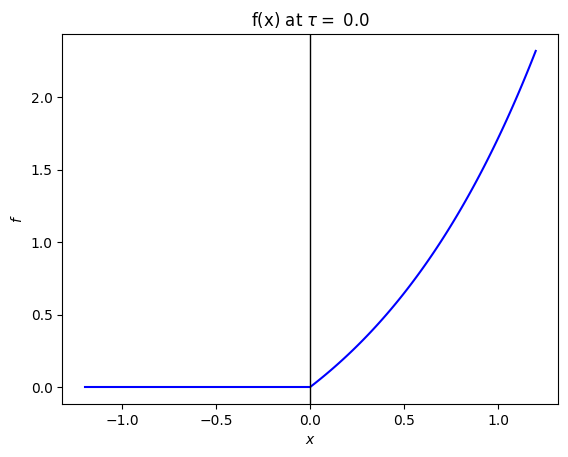

In [9]:
plot_frame(0)

## Transform PDE Problem to 2-chebyshev cell coordinates

$$ \partial_\tau f = \frac{1}{2} \sigma^2 (\frac{2}{w})^2 \partial^2_{xnum} f +(r - \frac{1}{2}\sigma^2) \frac{2}{w}\partial_{xnum} f - rf$$

$$ f(\tau, xnumleft =+1)  - f(\tau, xnumright = -1)  = 0$$

$$ \frac{2}{w}\partial_{xnumleft} f(\tau, xnumleft =+1) - \frac{2}{w}\partial_{xnumright} f(\tau, xnumright =-1) = 0$$

$$ f(\tau, xnumleft=-1) = 0$$

$$ f(\tau, xnumright = 1) - K(e^w - e^{-r \tau}) = 0 $$

## Method of Lines Solution with SDIRK

In [10]:
c1 = 1/4
c2 = 0.
c3 = 1/2
c4 = 1.
c5 = 1.

a11 = 1/4
a21 = -1/4
a22 = 1/4
a31 = 1/8
a32 = 1/8
a33 = 1/4
a41 = -3/2
a42 = 3/4
a43 = 3/2
a44 = 1/4
a51 = 0.
a52 = 1/6
a53 = 2/3
a54 = -1/12
a55 = 1/4

b1 = 0.
b2 = 1/6
b3 = 2/3
b4 = -1/12
b5 = 1/4

In [11]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(1, n-2, int(n-3/1 + 1))/(n-1))

#collocation matrices
Tcol = np.zeros((len(xcol),n))
for i in range(0, len(xcol)):
    Tcol[i,:] = calc_T_matrix(n, xcol[i])
    
Tdiffcol = np.matmul(Tcol, diff)
Tdiff2col = np.matmul(np.matmul(Tcol, diff), diff)


In [12]:
def calc_K(c, tau_inp, dtau_inp, K1, K2, K3, K4, key):

    dtau = dtau_inp

    if key == 1:
        tau = tau_inp + dtau*c1
    elif key == 2:
        tau = tau_inp + dtau*c2
    elif key == 3:
        tau = tau_inp + dtau*c3
    elif key == 4:
        tau = tau_inp + dtau*c4
    elif key == 5:
        tau = tau_inp + dtau*c5
    

    L = np.zeros((2*n, 2*n))
    R = np.zeros((2*n, 2*n))
    J = np.zeros((2*n))
        
    #prepare the matrices
    
###################################################################################################
  
    #left outermost

    L[0:len(xcol),0:n] = Tcol 
    R[0:len(xcol),0:n] = (1/2)*sig**2*(2/w)**2*Tdiff2col + (r - (1/2)*sig**2)*(2/w)*Tdiffcol + (-r)*Tcol
    
    row_count = len(xcol)    
    
#####################################################################################################################################
    
   
    #right outermost cell
    
    L[row_count:row_count + len(xcol),n:] = Tcol 
    R[row_count:row_count + len(xcol),n:] = (1/2)*sig**2*(2/w)**2*Tdiff2col + (r - (1/2)*sig**2)*(2/w)*Tdiffcol + (-r)*Tcol
    
    row_count = row_count + len(xcol)
    
#############################################################################################################################################
    
    #boundary conditions

    #left cell
    R[row_count, 0:n] = calc_T_matrix(n, -1.)

    row_count = row_count + 1

    #right cell
    R[row_count, n:] = calc_T_matrix(n, +1.) 
    J[row_count] =  K*(np.exp(w) - np.exp(-r*tau))

    row_count = row_count + 1
    
    
####################################################################################################################################################
    

    #interface conditions
    TL = calc_T_matrix(n, +1.0)
    TR = calc_T_matrix(n, -1.0)
    TLdiff = np.matmul(TL, diff) 
    TRdiff = np.matmul(TR, diff) 

    #continuity
    
    R[row_count, 0:n] = -1*TL
    R[row_count, n:] = 1*TR
        
    row_count = row_count + 1
    
   
    #differentiability

    R[row_count, 0:n] = -(2/w)*TLdiff 
    R[row_count, n: ] = +(2/w)*TRdiff
    
    row_count = row_count + 1
    
    if key == 1:
        Lbar = L - R*(dtau)*(a11)
        Rbar = np.matmul(R, c) - J
        K1 = np.linalg.solve(Lbar,Rbar)
        return K1
    elif key == 2:
        Lbar = L - R*(dtau)*(a22)
        Rbar = np.matmul(R, c + dtau*K1*a21) - J
        K2 = np.linalg.solve(Lbar,Rbar)
        return K2
    elif key == 3:
        Lbar = L - R*(dtau)*(a33)
        Rbar = np.matmul(R, c + dtau*K1*a31 + dtau*K2*a32) - J
        K3 = np.linalg.solve(Lbar,Rbar)
        return K3
    elif key == 4:
        Lbar = L - R*(dtau)*(a44)
        Rbar = np.matmul(R, c + dtau*K1*a41 + dtau*K2*a42 + dtau*K3*a43) - J
        K4 = np.linalg.solve(Lbar,Rbar)
        return K4
    elif key == 5:
        Lbar = L - R*(dtau)*(a55)
        Rbar = np.matmul(R, c + dtau*K1*a51 + dtau*K2*a52 + dtau*K3*a53 + dtau*K4*a54) - J
        K5 = np.linalg.solve(Lbar,Rbar)
        return K5
    

In [13]:
#Calculate Data for all Times

for i in range(0, len(tau)-1):
    K1 = calc_K(c[i,:],tau[i], dtau[i], None, None, None, None, 1)
    K2 = calc_K(c[i,:],tau[i], dtau[i], K1, None, None, None, 2)
    K3 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, None, None, 3)
    K4 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, None, 4)
    K5 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , 5)

    c[i+1,:] = c[i,:] + dtau[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(tau[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))


0
The time is: 0.0
The average of the Chebychev coefficients is: 0.023201169227365478
100
The time is: 0.1
The average of the Chebychev coefficients is: 0.02359636413482371
200
The time is: 0.2
The average of the Chebychev coefficients is: 0.02377258839146428
300
The time is: 0.3
The average of the Chebychev coefficients is: 0.02392090184866379
400
The time is: 0.4
The average of the Chebychev coefficients is: 0.024056947668544635
500
The time is: 0.5
The average of the Chebychev coefficients is: 0.024184168111207403
600
The time is: 0.6
The average of the Chebychev coefficients is: 0.024307619648786794
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 0.02442589271294528
800
The time is: 0.8
The average of the Chebychev coefficients is: 0.024540187946596924
900
The time is: 0.9
The average of the Chebychev coefficients is: 0.02465171852179402


## Analysis

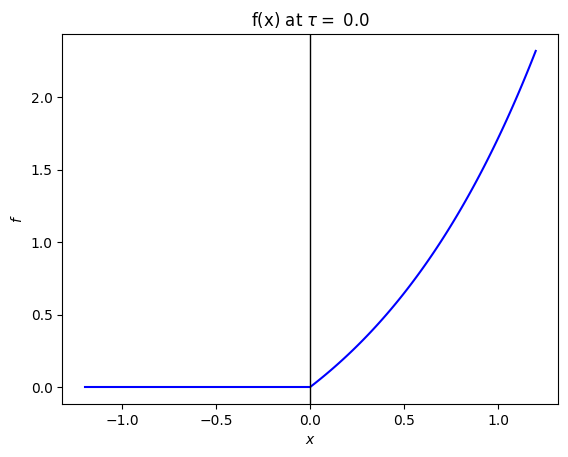

In [14]:
plot_frame(0)

In [15]:
def plot_coeff(tau_index):
    plt.plot(np.log10(np.abs(c[tau_index, 0:n])), c='red', label = 'left')
    plt.plot(np.log10(np.abs(c[tau_index, n:])), c='blue', label = 'right')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$log_{10}|c_k|$')
    plt.legend()
    plt.show()

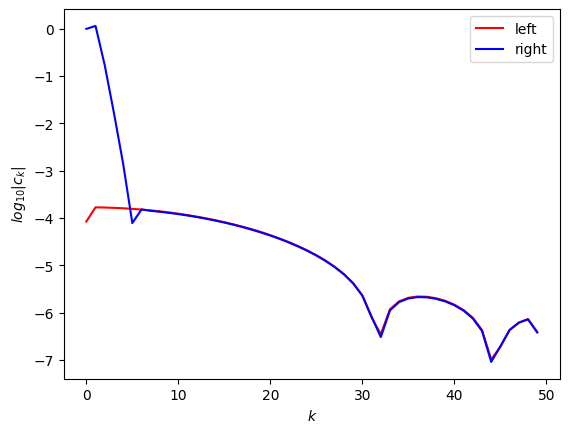

In [16]:
plot_coeff(1)

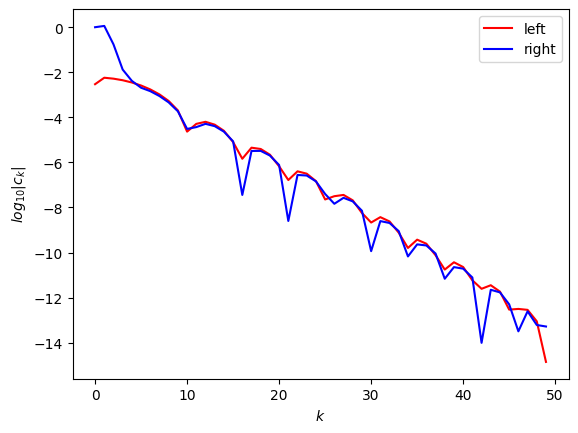

In [17]:
plot_coeff(100)

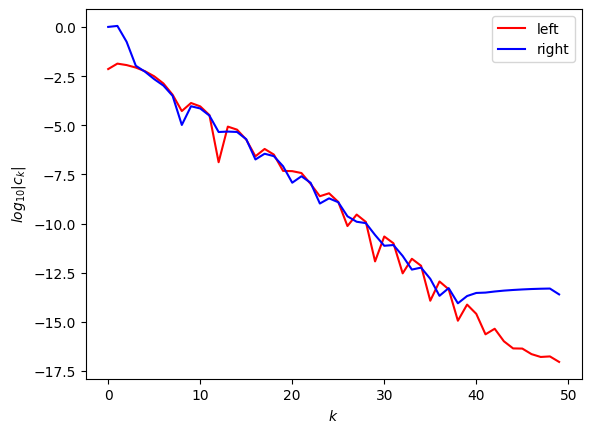

In [18]:
plot_coeff(300)

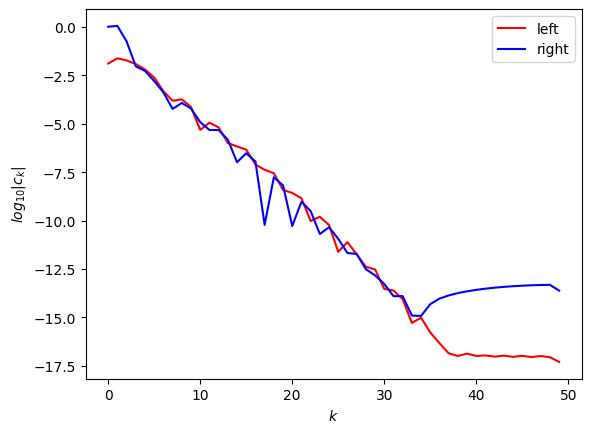

In [19]:
plot_coeff(600)

Fall of coefficients progressively gets better, as the solution becomes less and less kinky

In [20]:
def euro_call(x, tau, K, r, sig):
   
    d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d1 = d2 + sig*np.sqrt(tau)
    return K*np.exp(x)*scipy.stats.norm.cdf(d1) - K*np.exp(-r*tau)*scipy.stats.norm.cdf(d2)

In [21]:
def xleft_to_xnum(xleft):
    return (2/w)*xleft + 1.

def xright_to_xnum(xright):
    return (2/w)*xright - 1.


### Heatmap of errors with fixed N and timestep

In [ ]:
# heatmap of errors

#pass in solution array

def call_heatmap(c):

    numerical_solution = np.zeros((len(tau), 2*len(xplot)))
    analytical_solution = np.zeros((len(tau), 2*len(xplot)))

    for i in range(0, len(tau)):
        numerical_solution[i,:len(xplot)] = calc_u(c[i,0:n], xplot)
        analytical_solution[i,:len(xplot)] = euro_call(xnum_to_xleft(xplot), tau[i], K, r, sig)
        
        numerical_solution[i,len(xplot):] = calc_u(c[i,n:], xplot)
        analytical_solution[i,len(xplot):] = euro_call(xnum_to_xright(xplot), tau[i], K, r, sig)
        
    errors = np.abs(numerical_solution - analytical_solution)

    return numerical_solution, errors


In [25]:
num_call, errors_call = call_heatmap(c)

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\2170478369.py:3: RuntimeWarning: divide by zero encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\2170478369.py:3: RuntimeWarning: invalid value encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))


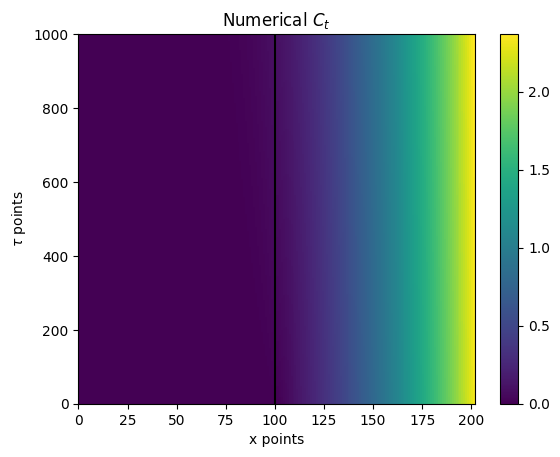

In [26]:
plt.pcolormesh(num_call)
plt.title('Numerical '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\958254640.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors_call))


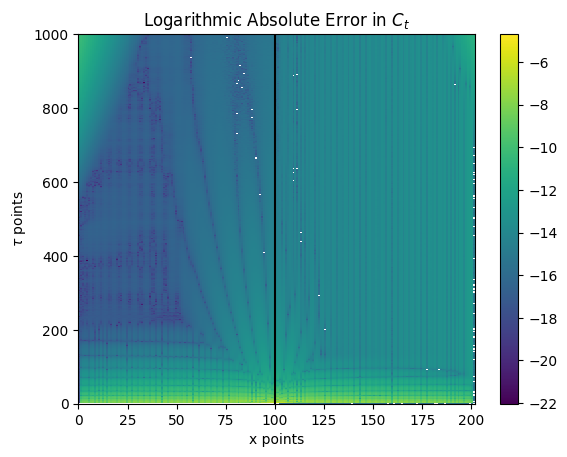

In [27]:
plt.pcolormesh(np.log10(errors_call))
plt.title('Logarithmic Absolute Error in '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

### $\Delta = \partial_S f$

For a European call option, $\Delta = \Phi(d_1)$

Numerically, we have $\Delta = \frac{1}{S}\partial_x f = \frac{1}{Ke^x} \partial_x f$ 

In [28]:
def delta_euro_call(x, tau, r, sig):
    
    d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d1 = d2 + sig*np.sqrt(tau)
    return scipy.stats.norm.cdf(d1) 

In [ ]:
# heatmap of errors

#pass in solution array

def delta_heatmap(c):

    numerical_solution = np.zeros((len(tau), 2*len(xplot)))
    analytical_solution = np.zeros((len(tau), 2*len(xplot)))

    #build matrix of derivatives at xplot nodes
    Tdiff = np.zeros((len(xplot), n)) 
    for k in range(0, len(xplot)):
        Tdiff[k,:] = calc_T_matrix(n, xplot[k])@diff

    for i in range(0, len(tau)):
        

        numerical_solution[i,:len(xplot)] = (1/(K*np.exp(xnum_to_xleft(xplot))))*(Tdiff@c[i,0:n])
        analytical_solution[i,:len(xplot)] = delta_euro_call(xnum_to_xleft(xplot), tau[i], r, sig)

        numerical_solution[i,len(xplot):] = (1/(K*np.exp(xnum_to_xright(xplot))))*(Tdiff@c[i,n:])
        analytical_solution[i,len(xplot):] = delta_euro_call(xnum_to_xright(xplot), tau[i], r, sig)

    errors = np.abs(numerical_solution - analytical_solution)

    return  numerical_solution, errors

In [32]:
num_delta, errors_delta,  = delta_heatmap(c)

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\3763436463.py:3: RuntimeWarning: divide by zero encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\3763436463.py:3: RuntimeWarning: invalid value encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))


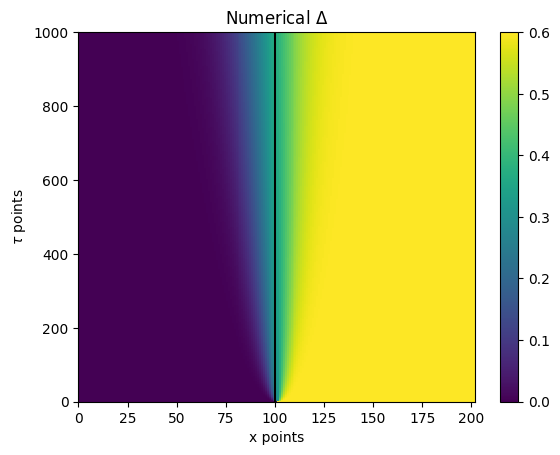

In [33]:
plt.pcolormesh(num_delta)
plt.title('Numerical '+r'$\Delta$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\3383528896.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors_delta))


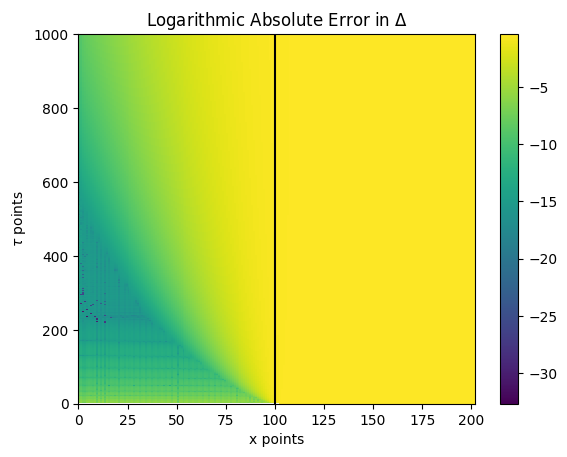

In [34]:
plt.pcolormesh(np.log10(errors_delta))
plt.title('Logarithmic Absolute Error in '+r'$\Delta$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

## Extracting Put Valuation Using Put-Call Parity

$P_\tau = C_\tau + Ke^{-r \tau} - S_\tau = C_\tau + K e^{-r \tau} - Ke^x = C_\tau + K(e^{-r \tau} - e^x)$

In [35]:
def euro_put(x, tau, K, r, sig):

    d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d1 = d2 + sig*np.sqrt(tau)
    
    return  K*np.exp(-r*tau)*scipy.stats.norm.cdf(-d2) - K*np.exp(x)*scipy.stats.norm.cdf(-d1)

In [36]:
def put_heatmap(c):

    numerical_solution = np.zeros((len(tau), 2*len(xplot)))
    analytical_solution = np.zeros((len(tau), 2*len(xplot)))


    for i in range(0, len(tau)):

        numerical_solution[i,:len(xplot)] = calc_u(c[i,0:n], xplot) + K*(np.exp(-r*tau[i]) -np.exp(xnum_to_xleft(xplot)))
        analytical_solution[i,:len(xplot)] = euro_put(xnum_to_xleft(xplot), tau[i], K, r, sig)

        numerical_solution[i,len(xplot):] = calc_u(c[i,n:], xplot) + K*(np.exp(-r*tau[i]) -np.exp(xnum_to_xright(xplot)))
        analytical_solution[i,len(xplot):] = euro_put(xnum_to_xright(xplot), tau[i], K, r, sig)

    errors = np.abs(numerical_solution - analytical_solution)
    
    return numerical_solution, analytical_solution, errors

    

In [37]:
num_put, ana_put, errors_put = put_heatmap(c)

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\3119223612.py:3: RuntimeWarning: divide by zero encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\3119223612.py:3: RuntimeWarning: invalid value encountered in divide
  d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))


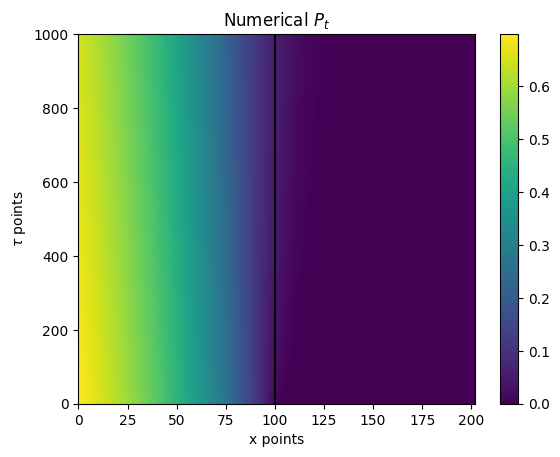

In [38]:
plt.pcolormesh(num_put)
plt.title('Numerical '+r'$P_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

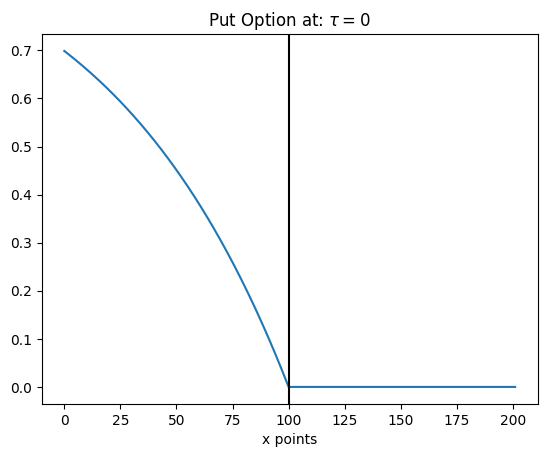

In [46]:
plt.plot(num_put[0,:])
plt.title('Put Option at: '+r'$\tau=0$')
plt.xlabel('x points')
plt.axvline(x=100, c='black')
plt.show()

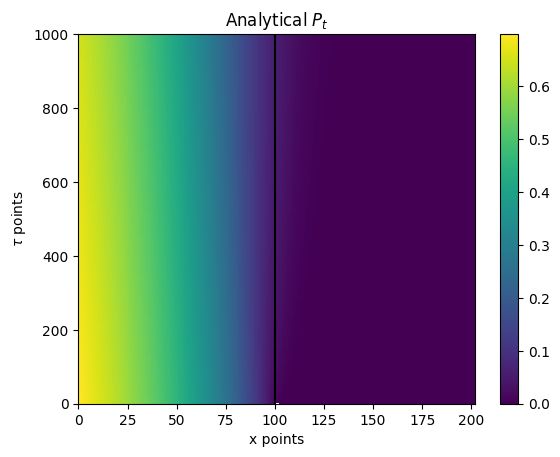

In [42]:
plt.pcolormesh(ana_put)
plt.title('Analytical '+r'$P_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

C:\Users\ar3n23\AppData\Local\Temp\ipykernel_16372\4087406176.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors_put), vmin=-18)


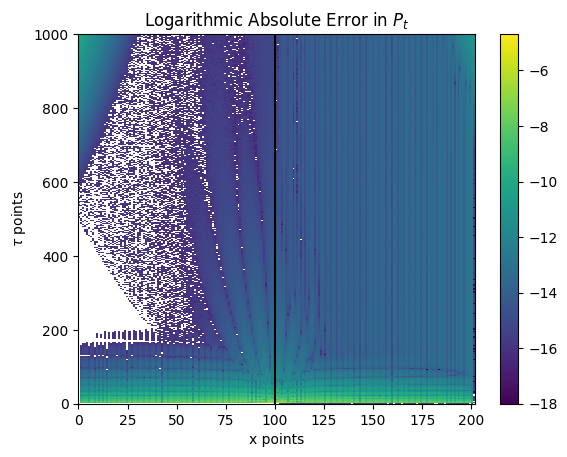

In [43]:
plt.pcolormesh(np.log10(errors_put), vmin=-18)
plt.title('Logarithmic Absolute Error in '+r'$P_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()